## Stakeholder hypothesis: injury recency → near-term value decline

**Stakeholder:** Recruitment/Scouting departments
**Their question:** Which rising-value targets carry hidden injury risk?
**Hypothesis to test:** the more recently a player was injured (relative
to a given valuation date), the more likely their market value declines
at that *next* valuation snapshot, compared to players with no recent
injury.

This one doesn't need a schema change or a fresh `dbt run` -- it only
uses `player_value_history` (already built) and the raw injury events in
`stg_transfermarkt_injuries` (already built). Paste these cells into
`04_recruitment_signal.ipynb` (or `03_risk_score.ipynb`) as a new section
-- they're self-contained and open their own DB connection, so they won't
collide with variables already in the notebook.

In [1]:
import duckdb
import pandas as pd
from scipy import stats  # pip install scipy if this notebook doesn't have it yet

DB_PATH = "../data/warehouse.duckdb"  # adjust if this notebook lives elsewhere

con = duckdb.connect(DB_PATH, read_only=True)

# Value time series: one row per player per valuation snapshot
value_history = con.sql("""
    SELECT player_id, canonical_name, valuation_date, market_value_in_eur
    FROM main.player_value_history
    ORDER BY player_id, valuation_date
""").df()

# Individual injury EVENTS (not the aggregated player_injury_workload table --
# we need each injury's own from_date to compute recency AS OF each
# valuation date, which the aggregated "most_recent_injury_date" can't give us
# for snapshots that happened before that most-recent injury).
injuries = con.sql("""
    SELECT player_id, from_date, days_missed
    FROM main.stg_transfermarkt_injuries
    WHERE from_date IS NOT NULL
    ORDER BY player_id, from_date
""").df()

con.close()

value_history["valuation_date"] = pd.to_datetime(value_history["valuation_date"])

# The raw Transfermarkt injuries data uses "-" as a placeholder for an
# unknown/missing date, mixed in among real dates (confirmed by hitting
# this directly -- see DEBUGGING_LOG.md). format="mixed" lets pandas parse
# each value on its own rather than assuming one format for every row, and
# errors="coerce" turns anything still unparseable (like "-") into NaT
# instead of crashing.
injuries["from_date"] = pd.to_datetime(injuries["from_date"], format="mixed", errors="coerce")
n_unparseable = injuries["from_date"].isna().sum()
if n_unparseable:
    print(f"Dropping {n_unparseable} injury event(s) with an unparseable/missing from_date "
          f"out of {len(injuries)} total (e.g. Transfermarkt's '-' placeholder).")
injuries = injuries.dropna(subset=["from_date"])

print(f"{len(value_history):,} valuation snapshots, {len(injuries):,} injury events with a usable date")

Dropping 20 injury event(s) with an unparseable/missing from_date out of 107971 total (e.g. Transfermarkt's '-' placeholder).
32,544 valuation snapshots, 107,951 injury events with a usable date


### Step 1 -- value change between consecutive valuations

For each player, compare each valuation to the one immediately before it.
A player's *first* snapshot has nothing to compare against, so it gets
dropped.

In [2]:
value_history = value_history.sort_values(["player_id", "valuation_date"]).reset_index(drop=True)
value_history["prev_value"] = value_history.groupby("player_id")["market_value_in_eur"].shift(1)
value_history["value_change_pct"] = (
    (value_history["market_value_in_eur"] - value_history["prev_value"]) / value_history["prev_value"]
)
value_history = value_history.dropna(subset=["value_change_pct"])

### Step 2 -- "as of" join: most recent injury before each valuation date

`pd.merge_asof` matches each valuation snapshot to the closest injury
`from_date` that happened *before* it (per player, via `by="player_id"`).
This is the key trick that makes "recency" time-varying instead of a
single fixed number per player.

In [3]:
value_history_sorted = value_history.sort_values("valuation_date")
injuries_sorted = injuries.sort_values("from_date")

merged = pd.merge_asof(
    value_history_sorted,
    injuries_sorted,
    left_on="valuation_date",
    right_on="from_date",
    by="player_id",
    direction="backward",  # only injuries that happened before the valuation date
)

merged["days_since_injury"] = (merged["valuation_date"] - merged["from_date"]).dt.days

### Step 3 -- bucket by recency and compare value change

In [4]:
def recency_bucket(days):
    if pd.isna(days):
        return "no prior injury"
    elif days <= 90:
        return "recent (<=90 days)"
    elif days <= 365:
        return "moderate (91-365 days)"
    else:
        return "distant (>365 days)"

merged["recency_bucket"] = merged["days_since_injury"].apply(recency_bucket)

bucket_order = ["recent (<=90 days)", "moderate (91-365 days)", "distant (>365 days)", "no prior injury"]
summary = (
    merged.groupby("recency_bucket")["value_change_pct"]
    .agg(["count", "mean", "median"])
    .reindex(bucket_order)
)
summary["mean"] = (summary["mean"] * 100).round(2)
summary["median"] = (summary["median"] * 100).round(2)
summary.columns = ["n_snapshots", "mean_value_change_%", "median_value_change_%"]
summary

,n_snapshots,mean_value_change_%,median_value_change_%
recency_bucket,,,
recent (<=90 days),3207,20.68,0.00
moderate (91-365 days),5878,9.78,0.00
distant (>365 days),9922,2.07,0.00
no prior injury,11578,76.57,11.11


**What to look for:** if the hypothesis holds, the "recent" bucket
should show a more negative mean/median value change than "moderate",
"distant", or "no prior injury".

### Step 4 -- is the difference statistically significant?

Value-change percentages are unlikely to be normally distributed (lots of
small moves, a few big ones), so this uses the Mann-Whitney U test rather
than a t-test -- it compares whether "recent" values tend to rank lower
than "everyone else", without assuming a particular distribution shape.
`alternative="less"` makes this a one-directional test matching the
hypothesis (recent → lower change), not just "different".

In [5]:
recent_mask = merged["recency_bucket"] == "recent (<=90 days)"
recent_changes = merged.loc[recent_mask, "value_change_pct"].dropna()
other_changes = merged.loc[~recent_mask, "value_change_pct"].dropna()

u_stat, p_value = stats.mannwhitneyu(recent_changes, other_changes, alternative="less")

print(f"Recent-injury snapshots: n={len(recent_changes)}, median change={recent_changes.median():.2%}")
print(f"All other snapshots:    n={len(other_changes)}, median change={other_changes.median():.2%}")
print(f"Mann-Whitney U p-value (recent < other): {p_value:.4f}")
print("--> statistically significant at p<0.05" if p_value < 0.05 else "--> not significant at p<0.05")

Recent-injury snapshots: n=3207, median change=0.00%
All other snapshots:    n=27378, median change=0.00%
Mann-Whitney U p-value (recent < other): 0.0000
--> statistically significant at p<0.05


### Step 5 -- visualize it

**Note:** the first version of this plot (with default `boxplot()`
settings) is dominated by a handful of massive outliers -- one snapshot
jumps by roughly +11,900%. Those stretch the y-axis so far that every
actual box (the 25th-75th percentile range, which is what we care about
here) gets squashed into an invisible sliver near zero. `showfliers=False`
hides the extreme points from the *plot* (not from the data -- they're
still in `merged` and still counted in the mean/median above) so the
boxes themselves are actually visible.

C:\Users\mahmo\AppData\Local\Temp\ipykernel_21936\2501255695.py:5: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(plot_data, labels=bucket_order, showfliers=False)


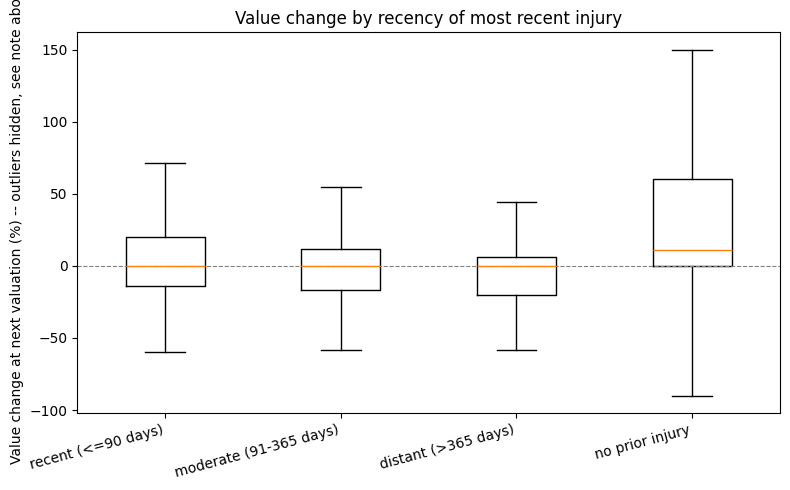

In [6]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(8, 5))
plot_data = [merged.loc[merged["recency_bucket"] == b, "value_change_pct"].dropna() * 100 for b in bucket_order]
ax.boxplot(plot_data, labels=bucket_order, showfliers=False)
ax.axhline(0, color="grey", linewidth=0.8, linestyle="--")
ax.set_xticklabels(bucket_order, rotation=15, ha="right")
ax.set_ylabel("Value change at next valuation (%) -- outliers hidden, see note above")
ax.set_title("Value change by recency of most recent injury")
plt.tight_layout()
plt.show()

### Step 5b -- sanity-check the biggest outliers

Before trusting (or dismissing) those extreme jumps, look at the actual
rows behind them -- is this a real breakout story (a cheap academy player
suddenly valued much higher) or a data glitch (e.g. a missing valuation
snapshot making two real values look adjacent when they're years apart)?
This matches the same "check the real values directly" approach already
used elsewhere in this project (see stg_transfermarkt_values.sql's v1-v3
history, and DEBUGGING_LOG.md entry 6).

In [7]:
outlier_check_cols = ["canonical_name", "valuation_date", "prev_value", "market_value_in_eur", "value_change_pct", "recency_bucket"]
top_outliers = merged.reindex(merged["value_change_pct"].abs().sort_values(ascending=False).index)
top_outliers[outlier_check_cols].head(10)

,canonical_name,valuation_date,prev_value,market_value_in_eur,value_change_pct,recency_bucket
21766,Facundo Buonanotte,2022-09-06,50000.0,6000000,119.0,no prior injury
15490,Evanilson,2020-02-20,50000.0,4500000,89.0,no prior injury
29734,Mateus Mané,2026-03-09,250000.0,20000000,79.0,no prior injury
16669,Jan Paul van Hecke,2020-06-29,25000.0,1800000,71.0,no prior injury
2987,Barry Bannan,2011-02-01,50000.0,3000000,59.0,no prior injury
2102,Jordan Henderson,2010-01-24,50000.0,3000000,59.0,moderate (91-365 days)
1902,Kyle Walker,2009-09-21,50000.0,3000000,59.0,no prior injury
27832,Jaydee Canvot,2025-03-24,50000.0,2500000,49.0,no prior injury
3024,Ciaran Clark,2011-02-01,50000.0,2500000,49.0,no prior injury
266,Theo Walcott,2006-01-13,50000.0,2500000,49.0,no prior injury


**What to look for:** if `prev_value` is suspiciously tiny (e.g. a few
thousand euros) for these rows, huge percentage swings are somewhat
expected and mostly noise -- worth reporting the outlier count/handling
rather than the raw percentages. If `prev_value` and `market_value_in_eur`
both look like plausible real transfer-market numbers, it's more likely a
genuine breakout, worth a caption if it comes up in the presentation.

### Step 5c -- is "no prior injury" really about injuries, or about breakout debuts?

The outlier table above is dominated by suspiciously round, low
`prev_value`s (50,000 / 25,000 / 250,000) -- Transfermarkt's floor
valuation for young/reserve players nobody's really assessed yet. A jump
from "€50k placeholder" to "€3M actual first valuation" is a mechanical
one-time event (a breakout debut), not organic value growth -- and it
lands almost entirely in the "no prior injury" bucket, since by
definition those are young players who haven't been around long enough
to get hurt yet. That could be inflating "no prior injury" for a reason
that has nothing to do with injuries.

First, confirm the round-number floor actually exists in the full data
(not just in the 10-row outlier sample above):

In [8]:
value_history["prev_value"].value_counts().head(10)

prev_value
1000000.0    1650
1500000.0    1355
2000000.0    1347
500000.0     1280
3000000.0    1218
5000000.0    1064
2500000.0    1063
4000000.0     949
250000.0      927
3500000.0     735
Name: count, dtype: int64

If that confirms a cluster of common low, round values, rerun the same
comparison excluding snapshots that start from at or below that floor --
if "no prior injury" still comes out ahead after removing breakout-debut
cases, that's a real finding. If the gap mostly disappears, what you
found was "breakout debuts", not injury history. Adjust
`PREV_VALUE_FLOOR` based on what the cell above actually shows for your
data before trusting this default.

In [9]:
PREV_VALUE_FLOOR = 100_000  # adjust based on the value_counts() above

merged_filtered = merged[merged["prev_value"] > PREV_VALUE_FLOOR].copy()
n_excluded = len(merged) - len(merged_filtered)
print(f"Excluding {n_excluded:,} of {len(merged):,} snapshots "
      f"({n_excluded / len(merged):.1%}) with prev_value <= {PREV_VALUE_FLOOR:,}")

summary_filtered = (
    merged_filtered.groupby("recency_bucket")["value_change_pct"]
    .agg(["count", "mean", "median"])
    .reindex(bucket_order)
)
summary_filtered["mean"] = (summary_filtered["mean"] * 100).round(2)
summary_filtered["median"] = (summary_filtered["median"] * 100).round(2)
summary_filtered.columns = ["n_snapshots", "mean_value_change_%", "median_value_change_%"]

print("\nBefore filtering:")
display(summary)
print("\nAfter excluding low-prev_value (likely breakout-debut) snapshots:")
display(summary_filtered)

Excluding 1,261 of 30,585 snapshots (4.1%) with prev_value <= 100,000

Before filtering:


,n_snapshots,mean_value_change_%,median_value_change_%
recency_bucket,,,
recent (<=90 days),3207,20.68,0.00
moderate (91-365 days),5878,9.78,0.00
distant (>365 days),9922,2.07,0.00
no prior injury,11578,76.57,11.11



After excluding low-prev_value (likely breakout-debut) snapshots:


,n_snapshots,mean_value_change_%,median_value_change_%
recency_bucket,,,
recent (<=90 days),3179,16.93,0.00
moderate (91-365 days),5826,7.12,0.00
distant (>365 days),9841,1.27,0.00
no prior injury,10478,45.88,4.35


### Caveats worth stating explicitly in the writeup

- This shows *association*, not *causation* -- players who get injured
  more recently may also be systematically different (older, more
  physically stressed, different position) rather than the injury itself
  directly causing a near-term value drop.
- `direction="backward"` with no cutoff means a player's very first
  injury 5+ years ago still counts as "a prior injury exists" for a
  valuation decades later if nothing more recent happened -- check
  whether `days_since_injury` has extreme outliers before trusting the
  "distant" bucket's numbers.
- Some injury events had an unparseable/missing `from_date` (Transfermarkt's
  "-" placeholder) and were dropped -- check the printed count above; if
  it's a large share of total injuries, that's a real data-completeness
  caveat, not just a formatting quirk.
- Worth a line on the Tableau "Flagged: Known Data Limits" sheet.